In [1]:
# Importación de librerías
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
# Lectura de datos
nivel_del_mar = pd.read_csv("../datos/data-1_metros.csv")
temperatura = pd.read_csv("../datos/data-1_gradoscelsius.csv")
humedad_rel = pd.read_csv("../datos/data-1_porcentaje.csv")
velocidad_viento = pd.read_csv("../datos/data-1_metrosxsegundo.csv")

impacto_Nacional=pd.read_excel('../datos/Basehistorica_2000_a_2024.xlsx', usecols=[0,1,2,3,4,5,6,8,9,15])

poblacion_Veracruz = pd.read_csv('../datos/conjunto_de_datos_iter_30CSV20.csv', usecols=[3,5,9])

In [3]:
# Procesamiento de los datos

#  1. Cambiar el nombre de las columnas en el dataframe 'nivel_del_mar'
nivel_del_mar.rename(columns={'Nivel del mar (radar promedio)':'Radar promedio', 'Nivel del mar (flotador)':'Flotador'},
                    inplace=True)

#  2. Creación de una nueva columna que contiene las fechas del archivo en formato 'datetime'
nivel_del_mar['Tiempo_datetime']=pd.to_datetime(nivel_del_mar['Tiempo'], format='%Y-%m-%d %H:%M:%S')
temperatura['Tiempo_datetime']=pd.to_datetime(temperatura['Tiempo'], format='%Y-%m-%d %H:%M:%S')
humedad_rel['Tiempo_datetime']=pd.to_datetime(humedad_rel['Tiempo'], format='%Y-%m-%d %H:%M:%S')
velocidad_viento['Tiempo_datetime']=pd.to_datetime(velocidad_viento['Tiempo'], format='%Y-%m-%d %H:%M:%S')

#==============
# Semáforos de alerta
#==============
#temperatura
temp_actual = float(temperatura.iloc[-1]['Temperatura atmosferica'])
if temp_actual >=35:
    sem_temp = "Nivel de alerta: 🔴"
elif temp_actual >=25:
    sem_temp = "Alerta por temperatura: 🟡"
else:
    sem_temp = "Nivel de alerta: 🟢"
#nivel del mar
nivel_actual = float(nivel_del_mar['Radar promedio'].dropna().iloc[-1])
if nivel_actual > 2:
    sem_nivel_mar = "Nivel de alerta: 🔴"
elif nivel_actual > 1:
    sem_nivel_mar= "Alerta por nivel del mar:🟡"
else:
    sem_nivel_mar = "Nivel de alerta: 🟢"
#tsunami
estado_tsunami = "Sin alerta"
if estado_tsunami == "Alerta":
    sem_tsunami = "Nivel de alerta: 🔴"
elif estado_tsunami == "Precaución":
    sem_tsunami = "Nivel de alerta: 🟡"
else:
    sem_tsunami = "Nivel de alerta por tsunami: 🟢"
#huracán
estado_huracan = "Sin alerta"
if estado_huracan == "Alerta":
    sem_huracan = "Nivel de alerta: 🔴"
elif estado_huracan == "Precaución":
    sem_huracan = "Nivel de alerta: 🟡"
else:
    sem_huracan = "Nivel de alerta por huracán: 🟢"
# 3. Recorte de los datos de nivel del mar para mostrar mediciones y pronostico
valor_pronostico = nivel_del_mar.iloc[3580:]
valor_medido = nivel_del_mar.iloc[0:3580]

#  4. Filtrado de datos de población de INEGI
poblacionXmunicipio = poblacion_Veracruz.loc[poblacion_Veracruz['NOM_LOC']=='Total del Municipio']
municipios_mas_poblados=poblacionXmunicipio.sort_values(by='POBTOT', ascending=False).iloc[0:10]

#  5. Filtrado de datos de impacto socioeconómico de CENAPRED
impacto_Veracruz=impacto_Nacional.loc[impacto_Nacional['Estado']=='Veracruz']
impacto_Veracruz_Hidrometeo=impacto_Veracruz.loc[impacto_Veracruz['Clasificación del fenómeno']=='Hidrometeorológico']

#   5.1. Clasificación de los fenómenos
num_tipo_fenomeno = impacto_Veracruz_Hidrometeo['Tipo de fenómeno'].value_counts().iloc[0:11]

#   5.2. Cuantificación de la población afectada
lluvias = impacto_Veracruz_Hidrometeo.loc[impacto_Veracruz_Hidrometeo['Tipo de fenómeno']=='Lluvias']
lluvias_poblacion_afect = lluvias['Población afectada '].replace('SD',0).sum()
poblacion_afect = {'Lluvias':lluvias_poblacion_afect}

inundacion = impacto_Veracruz_Hidrometeo.loc[impacto_Veracruz_Hidrometeo['Tipo de fenómeno']=='Inundación']
inundacion_poblacion_afect = inundacion['Población afectada '].replace('SD',0).sum()
poblacion_afect['Inundación']=inundacion_poblacion_afect

fuertes_vientos = impacto_Veracruz_Hidrometeo.loc[impacto_Veracruz_Hidrometeo['Tipo de fenómeno']=='Fuertes vientos ']
vientos_poblacion_afect = fuertes_vientos['Población afectada '].replace('SD',0).sum()
poblacion_afect['Fuertes vientos']=vientos_poblacion_afect

bajas_temperaturas = impacto_Veracruz_Hidrometeo.loc[impacto_Veracruz_Hidrometeo['Tipo de fenómeno']=='Bajas temperaturas ']
bajatemp_poblacion_afect = bajas_temperaturas['Población afectada '].replace('SD',0).sum()
poblacion_afect['Bajas temperaturas']=bajatemp_poblacion_afect

ciclon_tropical = impacto_Veracruz_Hidrometeo.loc[impacto_Veracruz_Hidrometeo['Tipo de fenómeno']=='Ciclón tropical']
ciclon_poblacion_afect = ciclon_tropical['Población afectada '].replace('SD',0).sum()
poblacion_afect['Ciclón tropical']=ciclon_poblacion_afect

#   5.3. Cuantificación de los daños en millones de pesos
lluvias_danos_econ = lluvias['Total de daños (millones de pesos)'].sum()
danos_economicos = {'Lluvias':lluvias_danos_econ}

inundacion_danos_econ = inundacion['Total de daños (millones de pesos)'].sum()
danos_economicos['Inundación']=inundacion_danos_econ

ciclon_danos_econ = ciclon_tropical['Total de daños (millones de pesos)'].sum()
danos_economicos['Ciclón tropical']=ciclon_danos_econ

#   5.4. Impacto socioeconómico
impacto_social = pd.Series(poblacion_afect).sort_values(ascending=False)
impacto_economico = pd.Series(danos_economicos).sort_values(ascending=False)

# De 2000 a 2024 el estado de Veracruz fue impactado más de 300 veces por fenómenos meteorológicos y del mar, lo que equivale a al menos ¡10 desastres por año!

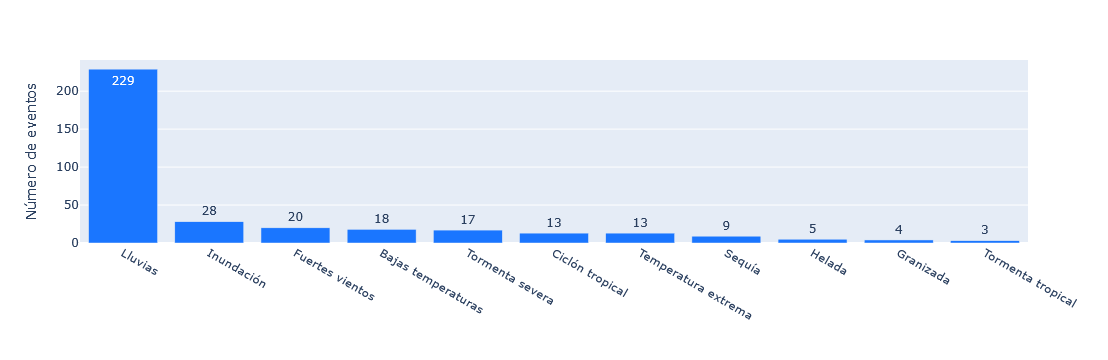

In [4]:
fig1=px.bar(num_tipo_fenomeno, color_discrete_sequence=['rgb(26, 118, 255)'], text_auto=True)
fig1.update_layout(xaxis_title=" ", yaxis_title="Número de eventos", showlegend=False)
fig1.show()

# Según el Atlas de Riesgos del estado de Veracruz, ¡la entidad ocupa el segundo lugar a nivel nacional en impactos por ciclones tropicales!

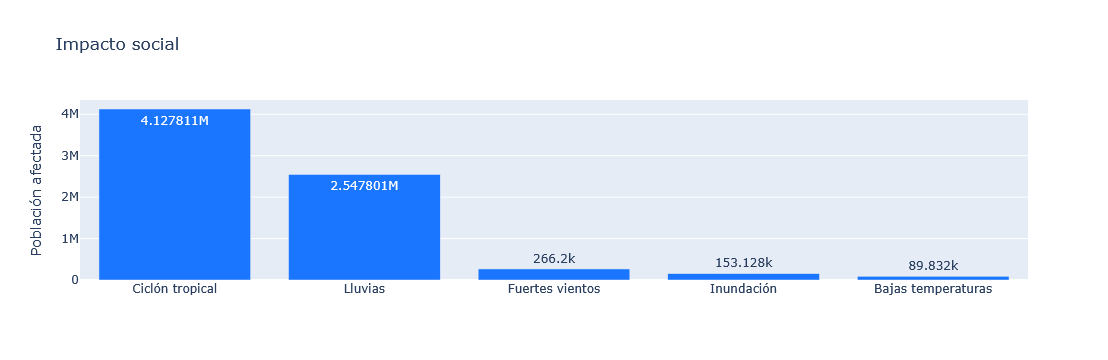

In [5]:
fig2=px.bar(impacto_social, color_discrete_sequence=['rgb(26, 118, 255)'], title="Impacto social", text_auto=True)
fig2.update_layout(xaxis_title=" ", yaxis_title="Población afectada", showlegend=False)
fig2.show()

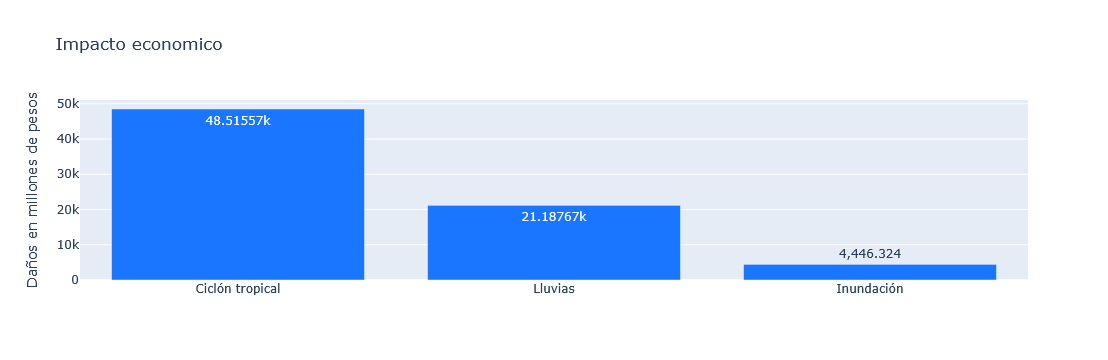

In [6]:
fig3=px.bar(impacto_economico, color_discrete_sequence=['rgb(26, 118, 255)'],title="Impacto economico", text_auto=True)
fig3.update_layout(xaxis_title=" ", yaxis_title="Daños en millones de pesos", showlegend=False)
fig3.show()

# De acuerdo con INEGI, en el municipio de Veracruz viven más de 600,000 personas, es decir, ¡más de medio millón de personas expuestas a impactos por fenómenos meteorológicos y del mar!

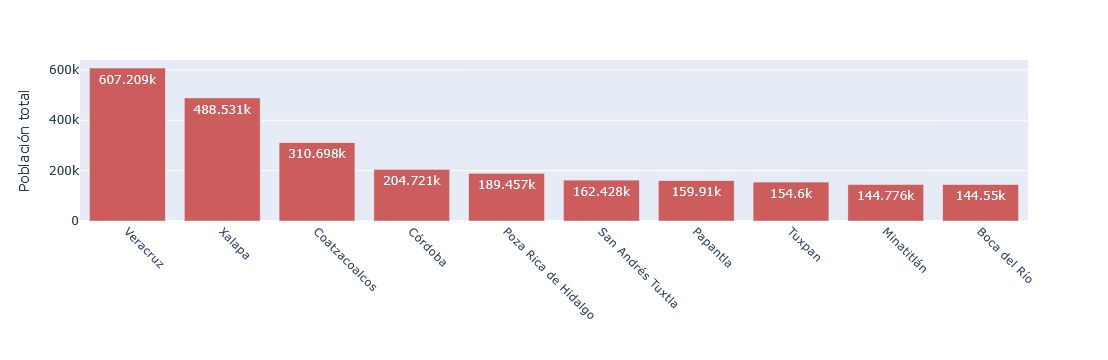

In [7]:
fig=px.bar(municipios_mas_poblados, x='NOM_MUN', y='POBTOT', color_discrete_sequence=['indianred'], text_auto=True)
fig.update_layout(xaxis_title=" ", yaxis_title="Población total", xaxis_tickangle=45)
fig.show()

# Es fundamental conocer las condiciones de pronóstico y actuales de variables meteorológicas y del mar

# Temperatura

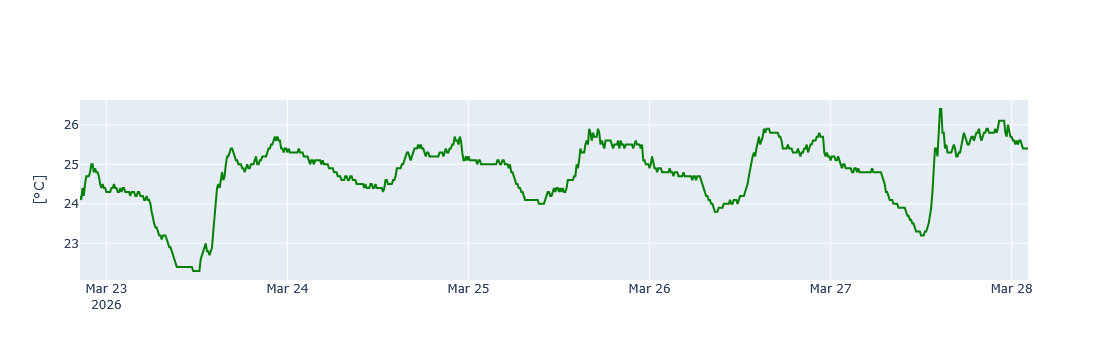

In [8]:
figT=go.Figure()
figT.add_trace(go.Scatter(x=temperatura['Tiempo_datetime'], y=temperatura['Temperatura atmosferica'], name='Medición', line=dict(color='green',width=2)))
figT.update_layout(xaxis_title=" ", yaxis_title="[°C]")
figT.show()

# Nivel del mar

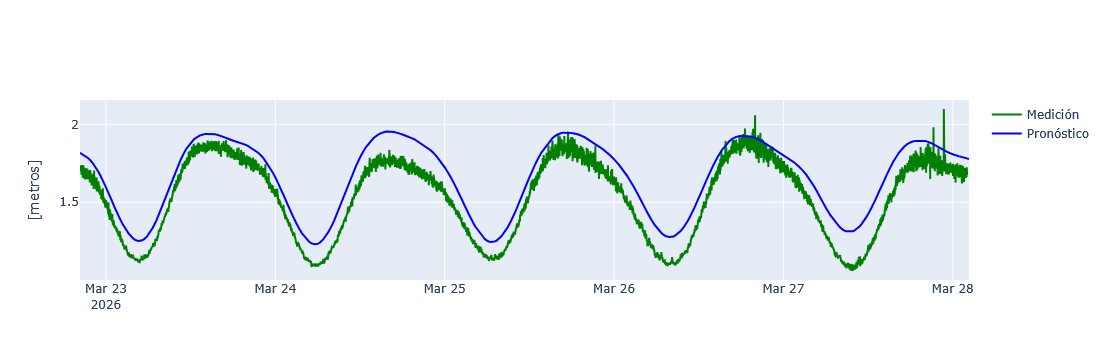

In [9]:
figM=go.Figure()
figM.add_trace(go.Scatter(x=nivel_del_mar['Tiempo_datetime'], y=nivel_del_mar['Radar promedio'], name='Medición', line=dict(color='green',width=2)))
figM.add_trace(go.Scatter(x=nivel_del_mar['Tiempo_datetime'], y=nivel_del_mar['Pronostico'], name='Pronóstico', line=dict(color='blue',width=2)))
figM.update_layout(xaxis_title=" ", yaxis_title="[metros]")
figM.show()

# Velocidad de rafaga

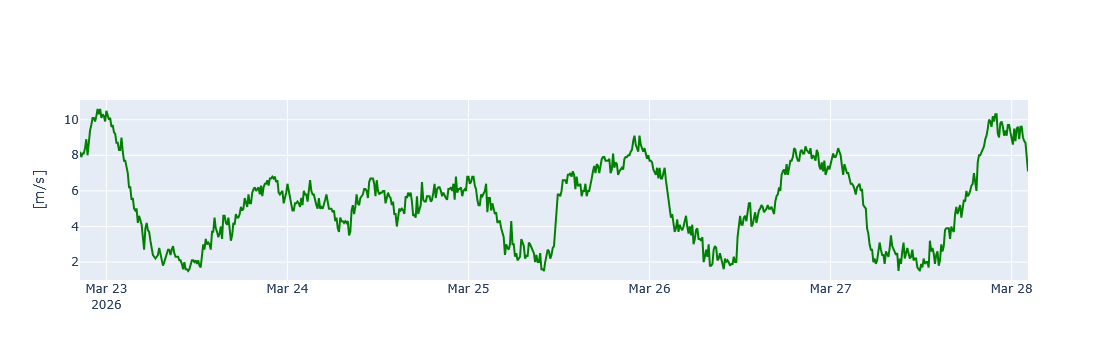

In [10]:
figV=go.Figure()
figV.add_trace(go.Scatter(x=velocidad_viento['Tiempo_datetime'], y=velocidad_viento['Velocidad de rafaga'], name='Velocidad de rafaga', line=dict(color='green',width=2)))
figV.update_layout(xaxis_title=" ", yaxis_title="[m/s]")
figV.show()

# Humedad relativa

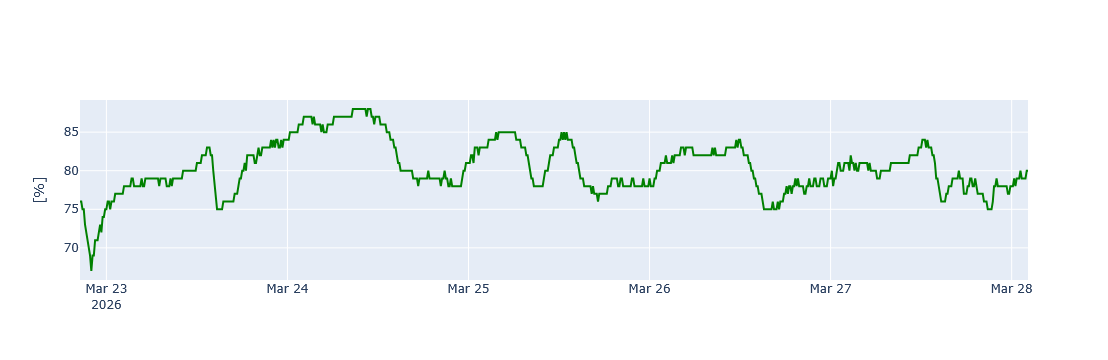

In [11]:
figH=go.Figure()
figH.add_trace(go.Scatter(x=humedad_rel['Tiempo_datetime'], y=humedad_rel['Humedad relativa'], name='Medición', line=dict(color='green',width=2)))
figH.update_layout(xaxis_title=" ", yaxis_title="[%]")
figH.show()